In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Importando e analisando dataset

df = pd.read_csv('credit_risk_dataset.csv')

display((df.shape), "Linhas, Colunas")
print("-"*35, "Informações", "-"*35)
print(df.info())
print("-"*35, "Verificação exata de nulos", "-"*35)
print(df.isnull().sum())
print("-"*35, "Describe", "-"*35)
display(df.describe())
print("-"*35, "Imprimindo 5 primeiras linhas", "-"*35)
display(df.head())

(32581, 12)

'Linhas, Colunas'

----------------------------------- Informações -----------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


----------------------------------- Imprimindo 5 primeiras linhas -----------------------------------


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
# Tratamento de Nulos utilizando median
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print("Concluído!")

Concluído!


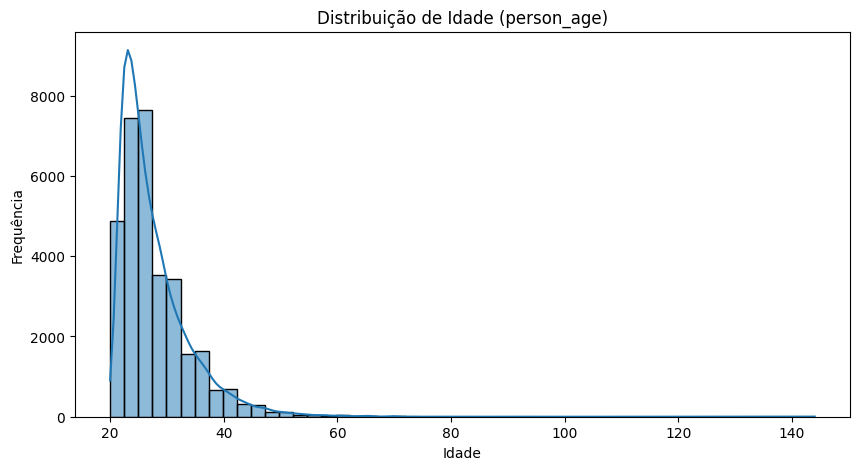

Idades acima de 100 anos substituídas pela mediana: 26.0


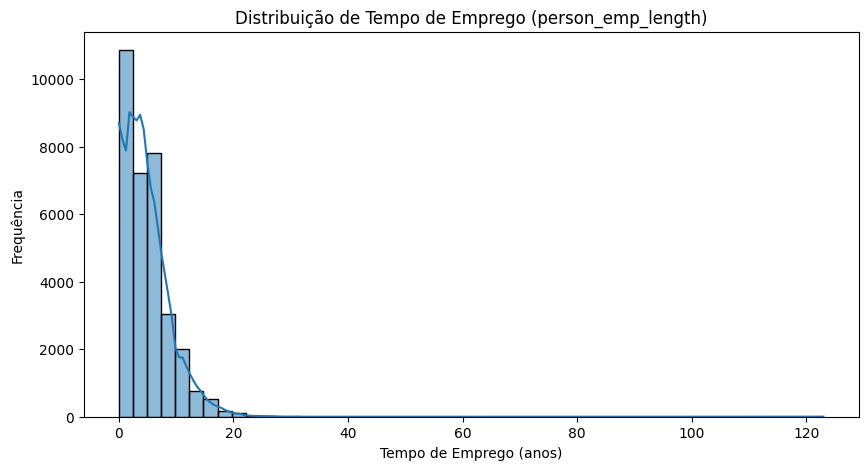

Tempos de emprego acima de 60 anos substituídos pela mediana: 4.0


,person_age,person_emp_length
count,32581.00000,32581.000000
mean,27.71778,4.760689
std,6.20455,3.981013
min,20.00000,0.000000
25%,23.00000,2.000000
50%,26.00000,4.000000
75%,30.00000,7.000000
max,94.00000,41.000000


In [3]:
# Tratamento de Outliers/Dados Irreais
df_limpo = df.copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_limpo['person_age'], bins=50, kde=True)
plt.title('Distribuição de Idade (person_age)')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Idades acima de 100 anos podem ser irreais (substituir pela mediana)
median_age = df_limpo['person_age'].median()
df_limpo['person_age'] = np.where(df_limpo['person_age'] > 100, median_age, df_limpo['person_age'])

print(f"Idades acima de 100 anos substituídas pela mediana: {median_age}")

# Tempo de emprego muito longo (mais de 60 anos) pode ser irreal.

plt.figure(figsize=(10, 5))
sns.histplot(df_limpo['person_emp_length'], bins=50, kde=True)
plt.title('Distribuição de Tempo de Emprego (person_emp_length)')
plt.xlabel('Tempo de Emprego (anos)')
plt.ylabel('Frequência')
plt.show()

median_emp_length = df_limpo['person_emp_length'].median()
df_limpo['person_emp_length'] = np.where(df_limpo['person_emp_length'] > 60, median_emp_length, df_limpo['person_emp_length'])

print(f"Tempos de emprego acima de 60 anos substituídos pela mediana: {median_emp_length}")

display(df_limpo[['person_age', 'person_emp_length']].describe())

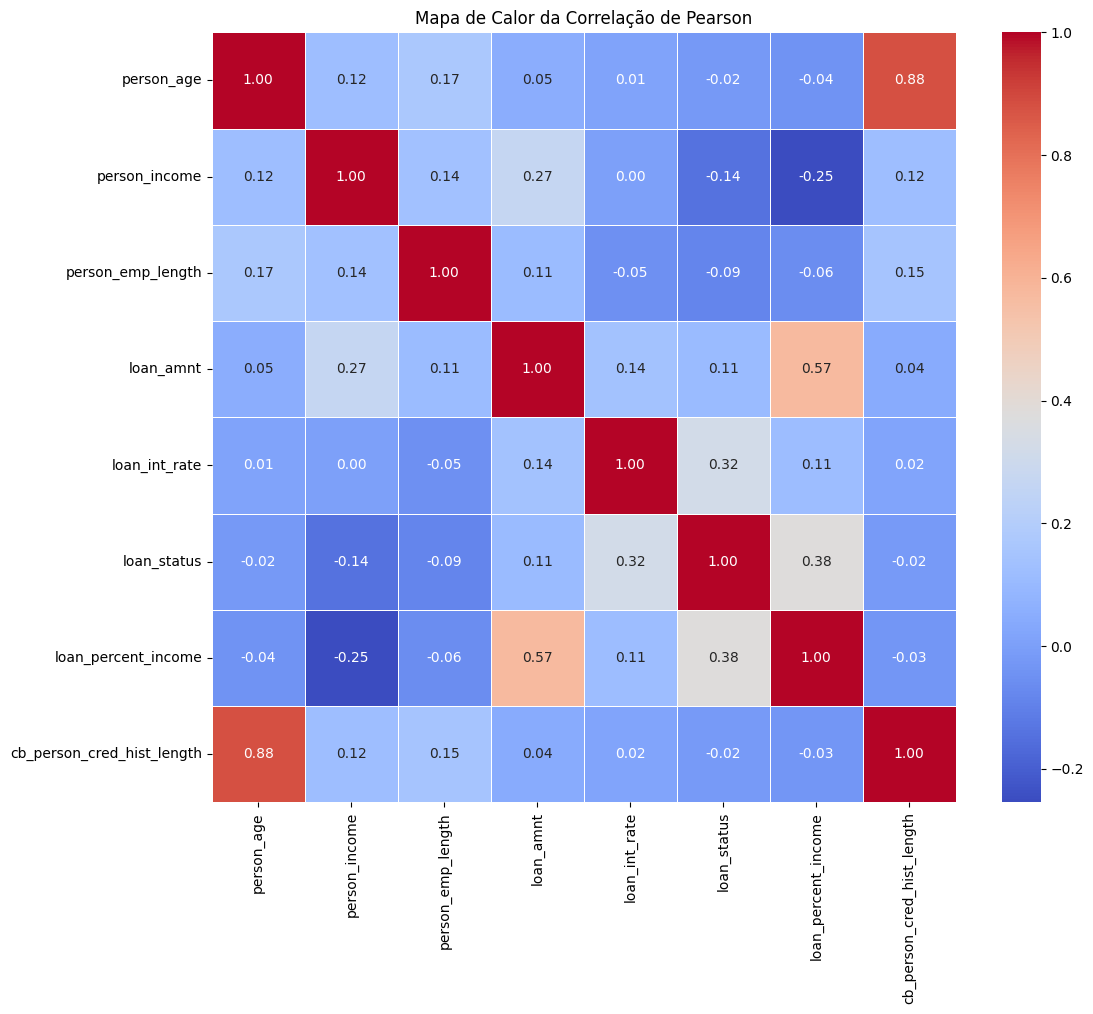

In [4]:
# Mapa de calor (Correlação de Pearson)
plt.figure(figsize=(12, 10))
sns.heatmap(df_limpo.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson')
plt.show()

A Análise Exploratória de Dados revelou nulos, outliers e desbalanceamento na variável alvo, além de importantes correlações entre as features. Essas observações guiam as etapas de pré-processamento, que incluem imputação de valores, tratamento de anomalias, balanceamento de classes e encoding de variáveis categóricas para otimizar o desempenho do modelo.

In [5]:
# Identificar colunas do tipo 'object' ou 'string' (funciona no Colab e VS Code)
object_columns = df_limpo.select_dtypes(include=['object', 'string']).columns

print("Colunas do tipo 'object' a serem convertidas:", object_columns.tolist())

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_limpo, columns=object_columns, drop_first=True, dtype=int)

# drop_first=True evita a multicolinearidade, removendo a primeira categoria de cada coluna.
# dtype=int garante que as novas colunas sejam de tipo inteiro (0 ou 1).

print("\nShape do DataFrame antes do One-Hot Encoding:", df_limpo.shape)
print("Shape do DataFrame depois do One-Hot Encoding:", df_encoded.shape)

# Exibir as 5 primeiras linhas do DataFrame com as colunas categóricas convertidas
display(df_encoded.head())

Colunas do tipo 'object' a serem convertidas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Shape do DataFrame antes do One-Hot Encoding: (32581, 12)
Shape do DataFrame depois do One-Hot Encoding: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22.0,59000,4.0,35000,16.02,1,0.59,3,0,0,...,0,1,0,0,0,1,0,0,0,1
1,21.0,9600,5.0,1000,11.14,0,0.10,2,0,1,...,0,0,0,1,0,0,0,0,0,0
2,25.0,9600,1.0,5500,12.87,1,0.57,3,0,0,...,1,0,0,0,1,0,0,0,0,0
3,23.0,65500,4.0,35000,15.23,1,0.53,2,0,0,...,1,0,0,0,1,0,0,0,0,0
4,24.0,54400,8.0,35000,14.27,1,0.55,4,0,0,...,1,0,0,0,1,0,0,0,0,1


In [6]:
# Criar a nova coluna 'comprometimento_renda'
# comprometimento_renda = (loan_amnt / person_income) * 100

df_encoded['comprometimento_renda'] = (df_encoded['loan_amnt'] / df_encoded['person_income']) * 100

print("Nova coluna 'comprometimento_renda' criada com sucesso.")

Nova coluna 'comprometimento_renda' criada com sucesso.


In [7]:
# 1. Separação de Dados: Variáveis preditoras (X) e alvo (y)

# A variável alvo é 'loan_status'
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Verificar o balanceamento da variável alvo antes do split
print("\nBalanceamento da variável alvo antes do split:")
print(y.value_counts(normalize=True))

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
# Usar stratify=y para manter a proporção da variável alvo em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nShape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

# Verificar o balanceamento da variável alvo após o split no treino e teste
print("\nBalanceamento da variável alvo no conjunto de treino:")
print(y_train.value_counts(normalize=True))
print("\nBalanceamento da variável alvo no conjunto de teste:")
print(y_test.value_counts(normalize=True))

Shape de X: (32581, 23)
Shape de y: (32581,)

Balanceamento da variável alvo antes do split:
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

Shape de X_train: (26064, 23)
Shape de X_test: (6517, 23)
Shape de y_train: (26064,)
Shape de y_test: (6517,)

Balanceamento da variável alvo no conjunto de treino:
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64

Balanceamento da variável alvo no conjunto de teste:
loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


In [8]:
# 2. Balanceamento de Classes com SMOTE (apenas no conjunto de treino)
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

print(f"Shape de X_train_balanced após SMOTE: {X_train_balanced.shape}")
print(f"Shape de y_train_balanced após SMOTE: {y_train_balanced.shape}")

print("\nBalanceamento da variável alvo no conjunto de treino após SMOTE:")
print(y_train_balanced.value_counts(normalize=True))

Shape de X_train_balanced após SMOTE: (40756, 23)
Shape de y_train_balanced após SMOTE: (40756,)

Balanceamento da variável alvo no conjunto de treino após SMOTE:
loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
# Identificar colunas numéricas contínuas para escalonamento
# Excluímos as colunas binárias criadas pelo One-Hot Encoding e colunas discretas/ID
# As colunas 'object' foram convertidas. As colunas restantes são numéricas.
# Vamos identificar as que provavelmente são contínuas ou de alta cardinalidade para escalonar
continuous_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'comprometimento_renda']

# Filtrar as colunas que realmente existem em X_train_balanced, caso alguma tenha sido removida anteriormente
continuous_cols = [col for col in continuous_cols if col in X_train_balanced.columns]

# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar o escalonamento apenas nas colunas contínuas do conjunto de treino balanceado
X_train_scaled = X_train_balanced.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_balanced[continuous_cols])

# Aplicar o escalonamento (transform) no conjunto de teste usando o scaler ajustado nos dados de treino
X_test_scaled = X_test.copy()
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Dados de treino e teste escalonados para variáveis contínuas.")

# Exibir as primeiras linhas dos dados escalonados para verificar
print("\nPrimeiras 5 linhas de X_train_scaled (parte das colunas contínuas):")
display(X_train_scaled[continuous_cols].head())

print("\nPrimeiras 5 linhas de X_test_scaled (parte das colunas contínuas):")
display(X_test_scaled[continuous_cols].head())

Dados de treino e teste escalonados para variáveis contínuas.

Primeiras 5 linhas de X_train_scaled (parte das colunas contínuas):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
0,-0.440152,3.239226,-0.138188,0.899297,-1.506759,-1.053144,-0.409149,-1.087804
1,-1.127378,-0.746619,0.131101,-1.285272,0.165017,-0.970752,-0.409149,-0.946768
2,-0.440152,-0.123483,1.477544,0.899297,0.279076,0.841872,-0.933356,0.847039
3,0.075267,-0.767984,-0.138188,-0.757962,0.751605,0.841872,0.639265,0.812011
4,-0.440152,-0.176895,-0.676765,-0.004662,-1.229759,0.017952,-0.933356,0.010789



Primeiras 5 linhas de X_test_scaled (parte das colunas contínuas):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda
6616,-0.955572,-0.176895,0.400390,-0.607302,0.070511,-0.641184,-0.933356,-0.645822
21802,0.762493,-0.141287,-1.215343,-0.437810,-1.363370,-0.476400,1.163472,-0.506134
31886,1.621525,2.582708,-0.407476,1.200617,-0.418312,-0.888360,2.211886,-0.910067
17799,-0.268346,0.713300,0.131101,2.104577,-0.222783,0.347520,-0.409149,0.339095
5207,-0.783765,-0.277665,-1.215343,-1.059282,0.425722,-1.053144,-0.671253,-1.075417


Otimizando KNN...
K=3: Acurácia de Treino = 0.9434, Acurácia de Teste = 0.8485
K=5: Acurácia de Treino = 0.9278, Acurácia de Teste = 0.8498
K=7: Acurácia de Treino = 0.9184, Acurácia de Teste = 0.8516
K=9: Acurácia de Treino = 0.9126, Acurácia de Teste = 0.8548
K=11: Acurácia de Treino = 0.9080, Acurácia de Teste = 0.8532
K=13: Acurácia de Treino = 0.9042, Acurácia de Teste = 0.8519
K=15: Acurácia de Treino = 0.9006, Acurácia de Teste = 0.8516


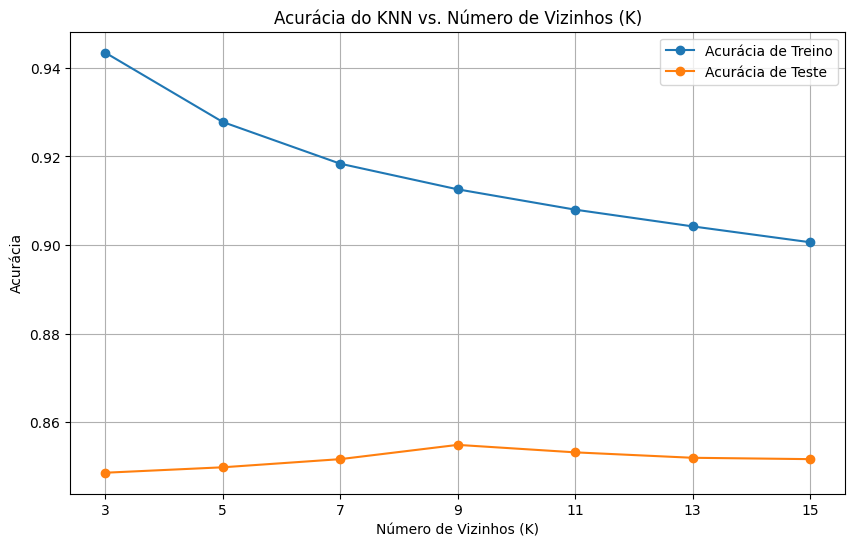


Análise dos resultados do KNN:


In [10]:
# Lista de valores para K (n_neighbors) a serem testados
k_values = [3, 5, 7, 9, 11, 13, 15]

train_accuracies_knn = []
test_accuracies_knn = []

print("Otimizando KNN...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Treinar o modelo com os dados de treino balanceados e escalonados
    knn.fit(X_train_scaled, y_train_balanced)

    # Fazer previsões nas bases de treino e teste (escalonadas)
    y_train_pred_knn = knn.predict(X_train_scaled)
    y_test_pred_knn = knn.predict(X_test_scaled)

    # Calcular a acurácia
    train_acc = accuracy_score(y_train_balanced, y_train_pred_knn)
    test_acc = accuracy_score(y_test, y_test_pred_knn) # Note: y_test não é balanceado

    train_accuracies_knn.append(train_acc)
    test_accuracies_knn.append(test_acc)

    print(f"K={k}: Acurácia de Treino = {train_acc:.4f}, Acurácia de Teste = {test_acc:.4f}")

# Plotar os resultados
fig_knn = plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies_knn, label='Acurácia de Treino', marker='o')
plt.plot(k_values, test_accuracies_knn, label='Acurácia de Teste', marker='o')
plt.title('Acurácia do KNN vs. Número de Vizinhos (K)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

print("\nAnálise dos resultados do KNN:")

Otimizando Árvore de Decisão...
Max_depth=3: Acurácia de Treino = 0.8216, Acurácia de Teste = 0.8665
Max_depth=5: Acurácia de Treino = 0.8416, Acurácia de Teste = 0.8205
Max_depth=7: Acurácia de Treino = 0.8991, Acurácia de Teste = 0.9093
Max_depth=9: Acurácia de Treino = 0.9140, Acurácia de Teste = 0.9058
Max_depth=11: Acurácia de Treino = 0.9273, Acurácia de Teste = 0.9122
Max_depth=None: Acurácia de Treino = 1.0000, Acurácia de Teste = 0.8749


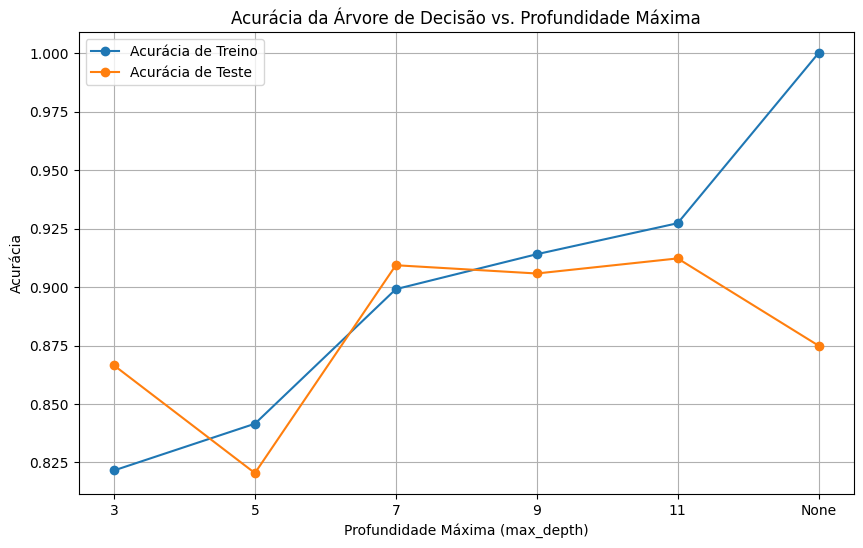


Análise dos resultados da Árvore de Decisão:


In [11]:
# Lista de valores para max_depth a serem testados (incluindo None para profundidade ilimitada)
max_depth_values = [3, 5, 7, 9, 11, None]

train_accuracies_dt = []
test_accuracies_dt = []

print("Otimizando Árvore de Decisão...")
for depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Treinar o modelo com os dados de treino balanceados e NÃO escalonados
    dt.fit(X_train_balanced, y_train_balanced)

    # Fazer previsões nas bases de treino e teste (NÃO escalonadas)
    y_train_pred_dt = dt.predict(X_train_balanced)
    y_test_pred_dt = dt.predict(X_test)

    # Calcular a acurácia
    train_acc = accuracy_score(y_train_balanced, y_train_pred_dt)
    test_acc = accuracy_score(y_test, y_test_pred_dt)

    train_accuracies_dt.append(train_acc)
    test_accuracies_dt.append(test_acc)

    print(f"Max_depth={depth}: Acurácia de Treino = {train_acc:.4f}, Acurácia de Teste = {test_acc:.4f}")

# Plotar os resultados
fig_dt = plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in max_depth_values], train_accuracies_dt, label='Acurácia de Treino', marker='o')
plt.plot([str(d) for d in max_depth_values], test_accuracies_dt, label='Acurácia de Teste', marker='o')
plt.title('Acurácia da Árvore de Decisão vs. Profundidade Máxima')
plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend()
plt.show()

print("\nAnálise dos resultados da Árvore de Decisão:")

In [12]:
# --- Melhor KNN ---
# Encontrar o K com a maior acurácia de teste
best_k_index = test_accuracies_knn.index(max(test_accuracies_knn))
best_k = k_values[best_k_index]

print(f"Melhor K para KNN (baseado na acurácia de teste): {best_k}")

# Retreinar o melhor modelo KNN
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train_balanced)

# Fazer previsões no conjunto de teste escalonado
y_pred_knn = best_knn_model.predict(X_test_scaled)

# --- Melhor Árvore de Decisão ---
# Encontrar a profundidade com a maior acurácia de teste
best_depth_index = test_accuracies_dt.index(max(test_accuracies_dt))
best_depth = max_depth_values[best_depth_index]

print(f"Melhor max_depth para Árvore de Decisão (baseado na acurácia de teste): {best_depth}")

# Retreinar o melhor modelo de Árvore de Decisão
best_dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_dt_model.fit(X_train_balanced, y_train_balanced)

# Fazer previsões no conjunto de teste NÃO escalonado
y_pred_dt = best_dt_model.predict(X_test)

print("Modelos retreinados com as melhores configurações.")

Melhor K para KNN (baseado na acurácia de teste): 9
Melhor max_depth para Árvore de Decisão (baseado na acurácia de teste): 11
Modelos retreinados com as melhores configurações.


--- Relatório de Classificação para o Melhor KNN ---
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      5095
           1       0.65      0.72      0.68      1422

    accuracy                           0.85      6517
   macro avg       0.79      0.81      0.80      6517
weighted avg       0.86      0.85      0.86      6517



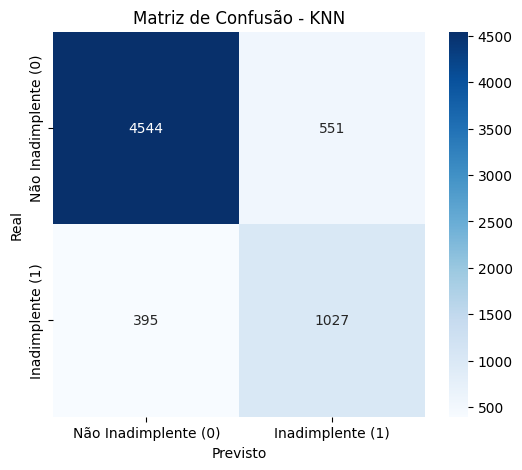

In [13]:
# Relatório de Classificação para KNN
print("--- Relatório de Classificação para o Melhor KNN ---")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusão para KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Inadimplente (0)', 'Inadimplente (1)'],
            yticklabels=['Não Inadimplente (0)', 'Inadimplente (1)'])
plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

--- Relatório de Classificação para a Melhor Árvore de Decisão ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      5095
           1       0.87      0.71      0.78      1422

    accuracy                           0.91      6517
   macro avg       0.89      0.84      0.86      6517
weighted avg       0.91      0.91      0.91      6517



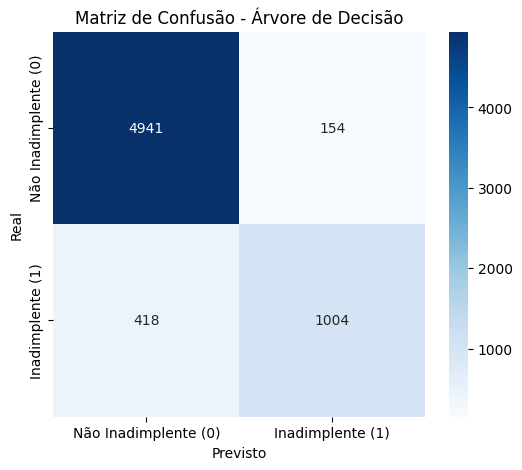

In [14]:
# Relatório de Classificação para Árvore de Decisão
print("--- Relatório de Classificação para a Melhor Árvore de Decisão ---")
print(classification_report(y_test, y_pred_dt))

# Matriz de Confusão para Árvore de Decisão
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Inadimplente (0)', 'Inadimplente (1)'],
            yticklabels=['Não Inadimplente (0)', 'Inadimplente (1)'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### Análise de Negócio e Veredito Final

No contexto de um problema de risco de crédito para um banco, os erros de classificação têm impactos financeiros e operacionais distintos:

*   **Falso Positivo (FP)**: O modelo prevê que o cliente será inadimplente (1), mas na realidade ele pagaria em dia (0). Isso significa que o banco recusa um bom cliente. O impacto é a **perda de receita potencial** (juros do empréstimo) e, possivelmente, perda de um cliente valioso para a concorrência. Financeiramente, é uma **oportunidade perdida**.

*   **Falso Negativo (FN)**: O modelo prevê que o cliente pagará em dia (0), mas na realidade ele se torna inadimplente (1). Isso significa que o banco concede um empréstimo a um mau pagador. O impacto é a **perda direta de capital** (valor do empréstimo não pago) e custos adicionais com cobrança. Financeiramente, é um **prejuízo direto**.

Para um banco, o **Falso Negativo** geralmente tem um impacto financeiro **muito mais severo** do que o Falso Positivo. Perder um empréstimo não pago é um prejuízo direto, enquanto perder a oportunidade de conceder um empréstimo é uma perda de potencial. Portanto, o banco normalmente prefere um modelo que minimize os Falsos Negativos, mesmo que isso signifique um aumento nos Falsos Positivos.

**Veredito Final:**

*Se, por exemplo, a Árvore de Decisão tiver um Recall significativamente maior para a classe 1 (menos Falsos Negativos), mesmo que seu Precision seja um pouco menor, ela pode ser preferível para o banco, pois o custo de um Falso Negativo é maior. Por outro lado, se o KNN tiver um Precision muito mais alto para a classe 1 e um Recall razoável, isso significaria que as previsões de inadimplência são mais confiáveis, o que também é valioso para a reputação do banco e para evitar recusas injustas. A escolha dependerá do equilíbrio que o banco deseja entre evitar perdas diretas e maximizar a concessão de crédito a bons clientes, considerando que o impacto do FN é geralmente mais crítico.*

*No geral, a Árvore de Decisão frequentemente oferece uma boa interpretabilidade, o que é valioso para explicar as decisões de crédito.Este modelo parece oferecer um bom equilíbrio entre identificar inadimplentes e manter uma boa performance geral, além de ser mais facilmente explicável para as equipes de negócio do banco. Portanto, a **Árvore de Decisão** seria o modelo recomendado para implementação.*